# Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from imblearn.over_sampling import SMOTE

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Data Overview

## Load Dataset

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/dicodingacademy/dicoding_dataset/refs/heads/main/employee/employee_data.csv')
df.head()

,EmployeeId,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,1,38,NaN,Travel_Frequently,1444,Human Resources,1,4,Other,1,...,2,80,1,7,2,3,6,2,1,2
1,2,37,1.0,Travel_Rarely,1141,Research & Development,11,2,Medical,1,...,1,80,0,15,2,1,1,0,0,0
2,3,51,1.0,Travel_Rarely,1323,Research & Development,4,4,Life Sciences,1,...,3,80,3,18,2,4,10,0,2,7
3,4,42,0.0,Travel_Frequently,555,Sales,26,3,Marketing,1,...,4,80,1,23,2,4,20,4,4,8
4,5,40,NaN,Travel_Rarely,1194,Research & Development,2,4,Medical,1,...,2,80,3,20,2,3,5,3,0,2


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   EmployeeId                1470 non-null   int64  
 1   Age                       1470 non-null   int64  
 2   Attrition                 1058 non-null   float64
 3   BusinessTravel            1470 non-null   object 
 4   DailyRate                 1470 non-null   int64  
 5   Department                1470 non-null   object 
 6   DistanceFromHome          1470 non-null   int64  
 7   Education                 1470 non-null   int64  
 8   EducationField            1470 non-null   object 
 9   EmployeeCount             1470 non-null   int64  
 10  EnvironmentSatisfaction   1470 non-null   int64  
 11  Gender                    1470 non-null   object 
 12  HourlyRate                1470 non-null   int64  
 13  JobInvolvement            1470 non-null   int64  
 14  JobLevel

## Statistic

In [4]:
df.describe()

,EmployeeId,Age,Attrition,DailyRate,DistanceFromHome,Education,EmployeeCount,EnvironmentSatisfaction,HourlyRate,JobInvolvement,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1058.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,735.500000,36.923810,0.169187,802.485714,9.192517,2.912925,1.0,2.721769,65.891156,2.729932,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,424.496761,9.135373,0.375094,403.509100,8.106864,1.024165,0.0,1.093082,20.329428,0.711561,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,1.000000,18.000000,0.000000,102.000000,1.000000,1.000000,1.0,1.000000,30.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,368.250000,30.000000,0.000000,465.000000,2.000000,2.000000,1.0,2.000000,48.000000,2.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,735.500000,36.000000,0.000000,802.000000,7.000000,3.000000,1.0,3.000000,66.000000,3.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,1102.750000,43.000000,0.000000,1157.000000,14.000000,4.000000,1.0,4.000000,83.750000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,1470.000000,60.000000,1.000000,1499.000000,29.000000,5.000000,1.0,4.000000,100.000000,4.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [5]:
df.describe(include='object')

,BusinessTravel,Department,EducationField,Gender,JobRole,MaritalStatus,Over18,OverTime
count,1470,1470,1470,1470,1470,1470,1470,1470
unique,3,3,6,2,9,3,1,2
top,Travel_Rarely,Research & Development,Life Sciences,Male,Sales Executive,Married,Y,No
freq,1043,961,606,882,326,673,1470,1054


## Missing Value

In [6]:
df.isnull().sum()

EmployeeId                    0
Age                           0
Attrition                   412
BusinessTravel                0
DailyRate                     0
Department                    0
DistanceFromHome              0
Education                     0
EducationField                0
EmployeeCount                 0
EnvironmentSatisfaction       0
Gender                        0
HourlyRate                    0
JobInvolvement                0
JobLevel                      0
JobRole                       0
JobSatisfaction               0
MaritalStatus                 0
MonthlyIncome                 0
MonthlyRate                   0
NumCompaniesWorked            0
Over18                        0
OverTime                      0
PercentSalaryHike             0
PerformanceRating             0
RelationshipSatisfaction      0
StandardHours                 0
StockOptionLevel              0
TotalWorkingYears             0
TrainingTimesLastYear         0
WorkLifeBalance               0
YearsAtC

In [7]:
df['Attrition'].isnull().sum()

np.int64(412)

In [8]:
missing_percentage = df['Attrition'].isnull().mean() * 100
print(missing_percentage)

28.027210884353742


In [9]:
df.dtypes

EmployeeId                    int64
Age                           int64
Attrition                   float64
BusinessTravel               object
DailyRate                     int64
Department                   object
DistanceFromHome              int64
Education                     int64
EducationField               object
EmployeeCount                 int64
EnvironmentSatisfaction       int64
Gender                       object
HourlyRate                    int64
JobInvolvement                int64
JobLevel                      int64
JobRole                      object
JobSatisfaction               int64
MaritalStatus                object
MonthlyIncome                 int64
MonthlyRate                   int64
NumCompaniesWorked            int64
Over18                       object
OverTime                     object
PercentSalaryHike             int64
PerformanceRating             int64
RelationshipSatisfaction      int64
StandardHours                 int64
StockOptionLevel            

## Duplicated Value

In [10]:
duplicate_count = df.duplicated().sum()
print(duplicate_count)

0


# Exploratory Data Analysis

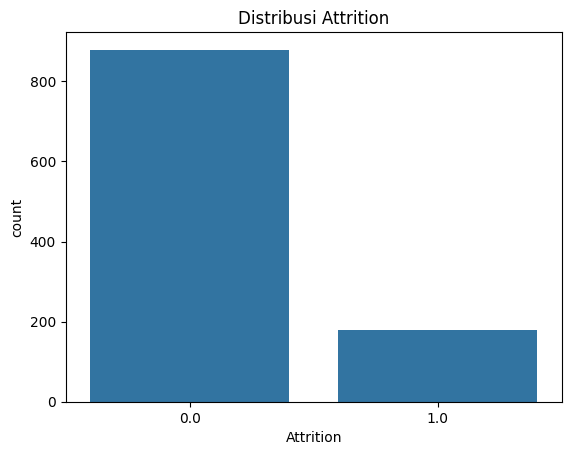

In [11]:
# @title Target Distribution
sns.countplot(x='Attrition', data=df)
plt.title('Distribusi Attrition')
plt.show()

In [12]:
# Cek Imbalance

df['Attrition'].value_counts(normalize=True) * 100

Attrition
0.0    83.081285
1.0    16.918715
Name: proportion, dtype: float64

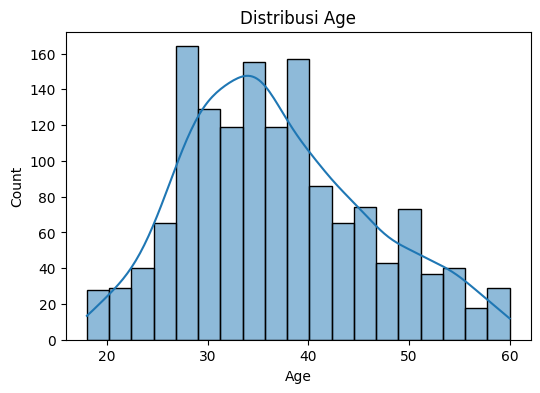

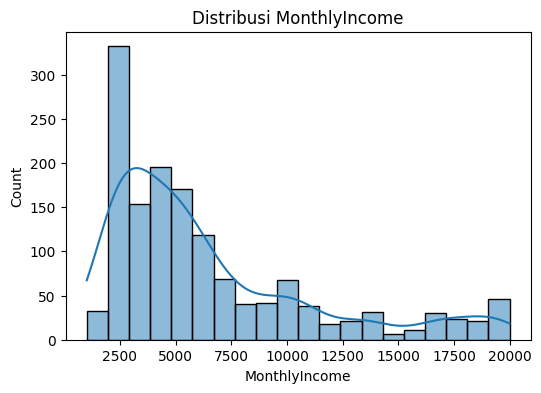

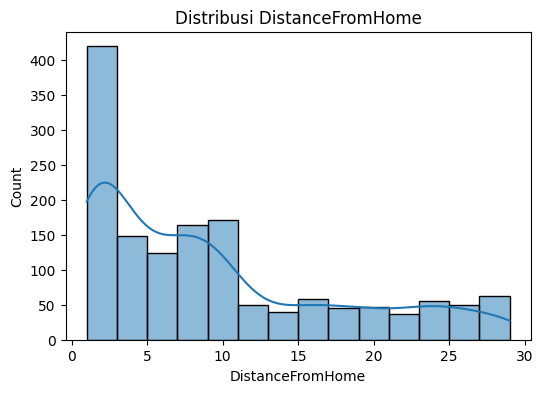

In [13]:
# $title Distribusi Numerikal

num_cols = ['Age', 'MonthlyIncome', 'DistanceFromHome']

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribusi {col}')
    plt.show()

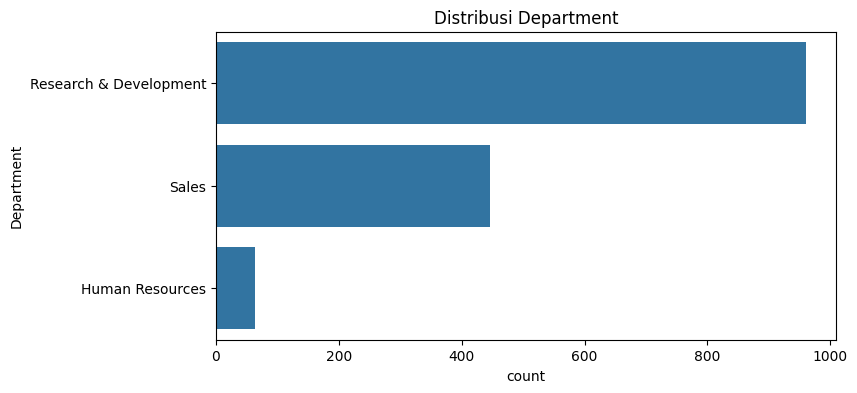

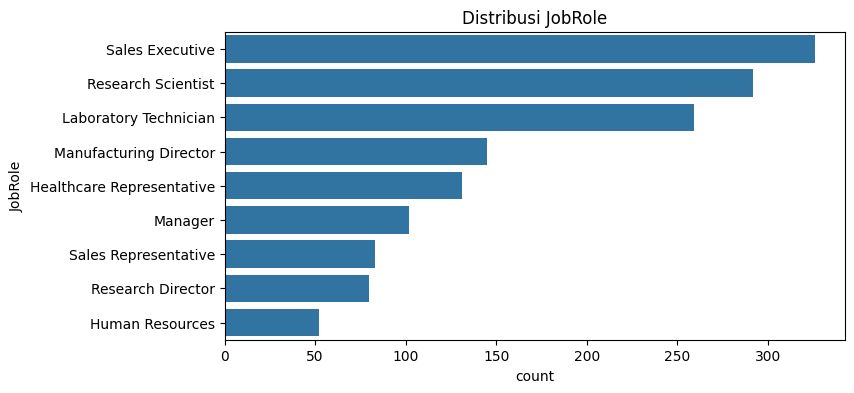

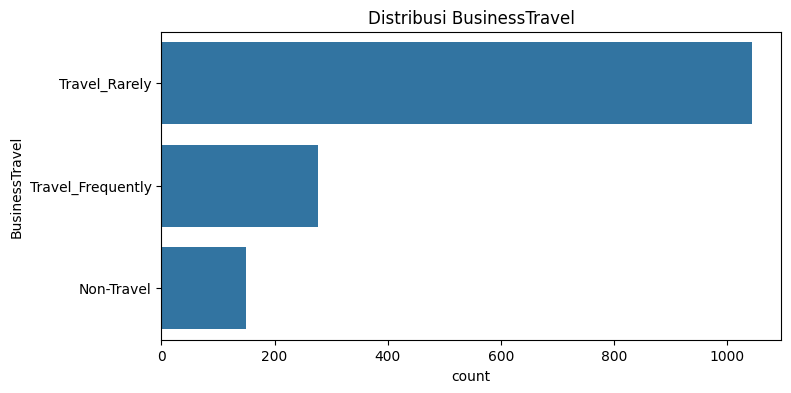

In [14]:
# $title Distribusi Kategorikal

cat_cols = ['Department', 'JobRole', 'BusinessTravel']

for col in cat_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(data=df, y=col, order=df[col].value_counts().index)
    plt.title(f'Distribusi {col}')
    plt.show()

## EDA Multivariate

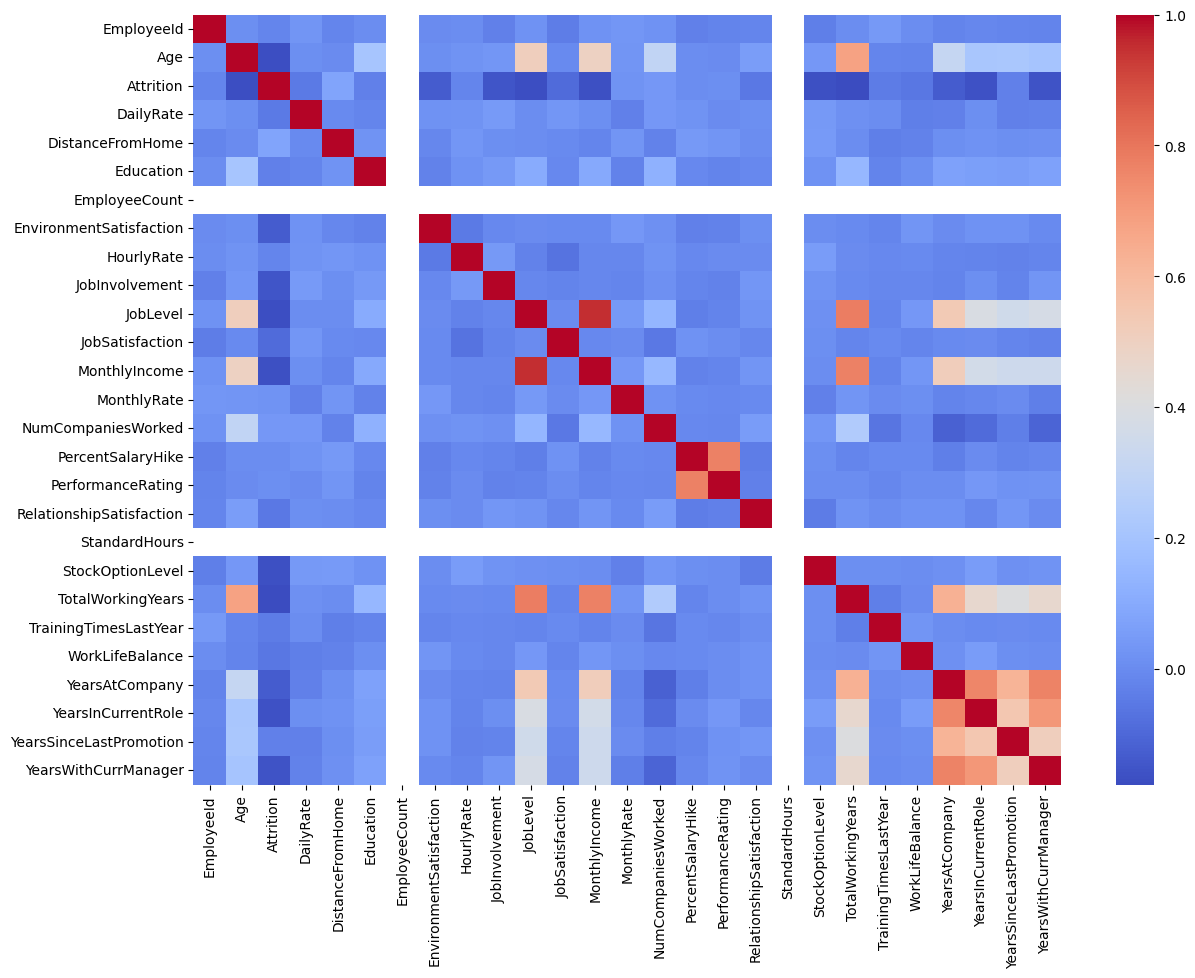

In [15]:
# @title Numerical Correlation

plt.figure(figsize=(14,10))
sns.heatmap(
    df.corr(numeric_only=True),
    cmap='coolwarm'
)
plt.show()

In [16]:
# # @title Attrition and Age

# plt.figure(figsize=(6,4))
# sns.boxplot(data=df, x='Attrition_Label', y='Age')
# plt.xticks([0,1], ['Stay', 'Exit'])
# plt.title('Perbandingan Umur vs Attrition')
# plt.show()

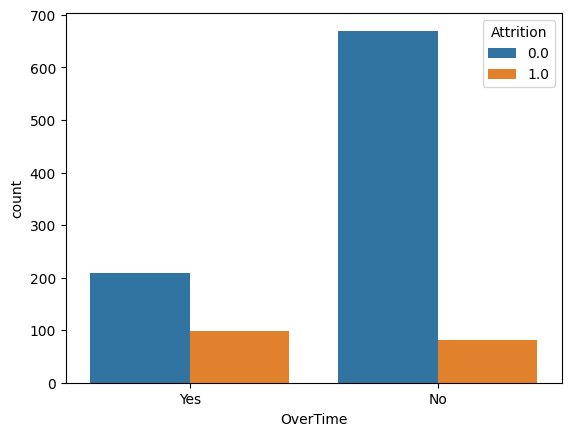

In [17]:
# @title Attrition and OverTime Work

sns.countplot(x='OverTime', hue='Attrition', data=df)
plt.show()

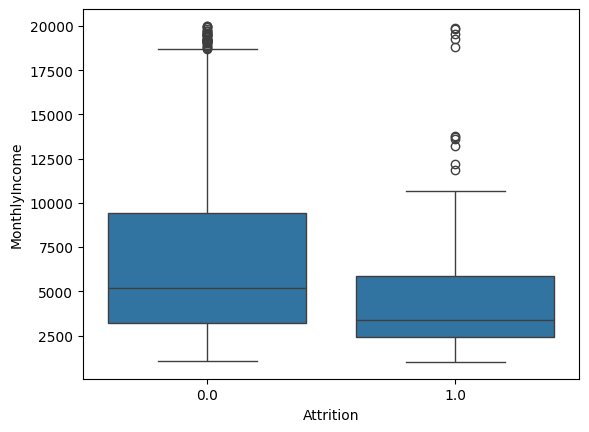

In [18]:
# @title Attrition and Monthly Income

sns.boxplot(x='Attrition', y='MonthlyIncome', data=df)
plt.show()

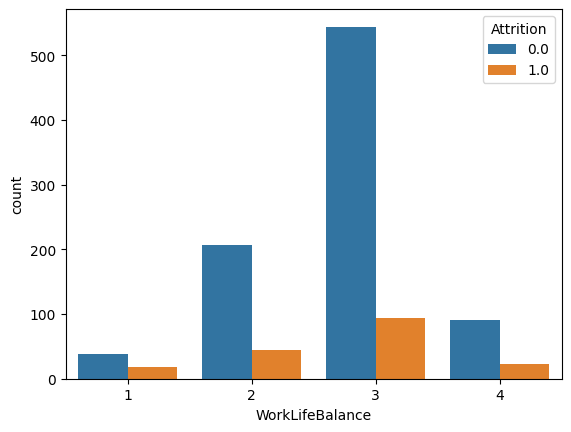

In [19]:
# @title Attrition and Work Life Balance

sns.countplot(
    x='WorkLifeBalance',
    hue='Attrition',
    data=df
)
plt.show()

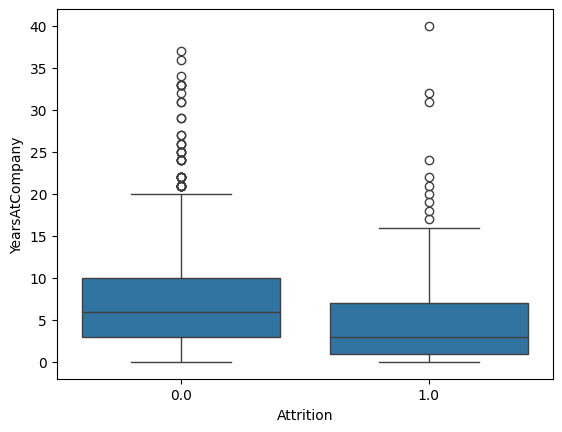

In [20]:
# @title Attrition and Years At Company

sns.boxplot(
    x='Attrition',
    y='YearsAtCompany',
    data=df
)
plt.show()

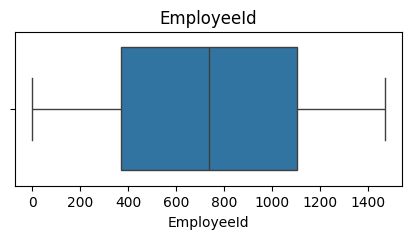

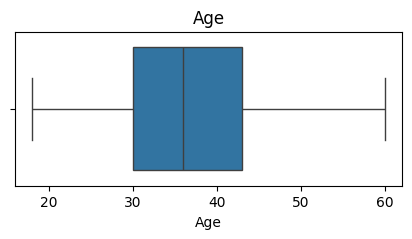

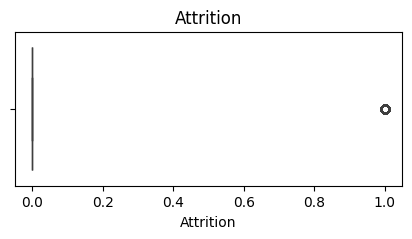

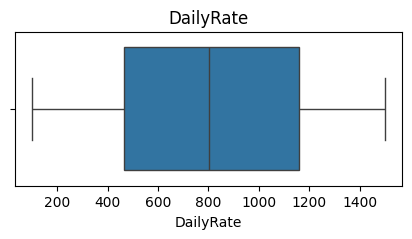

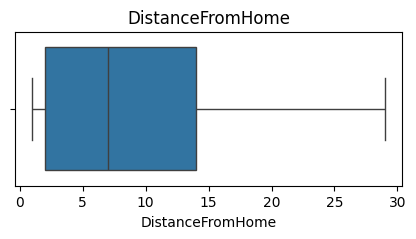

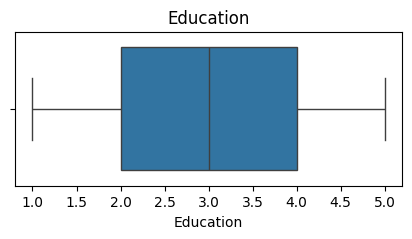

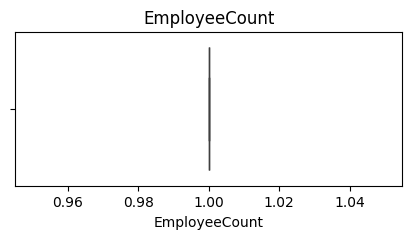

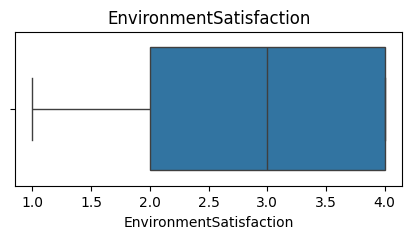

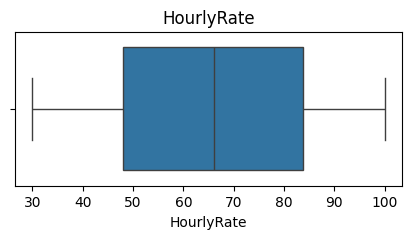

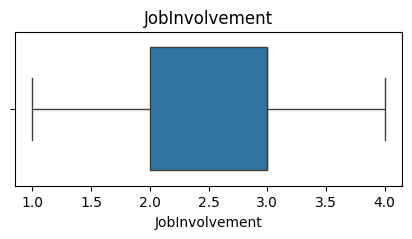

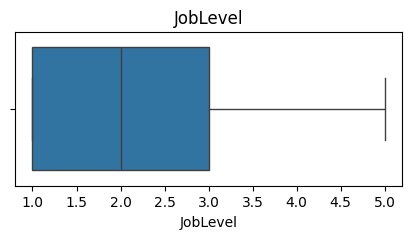

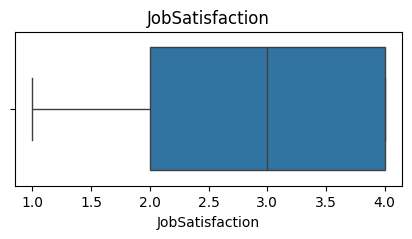

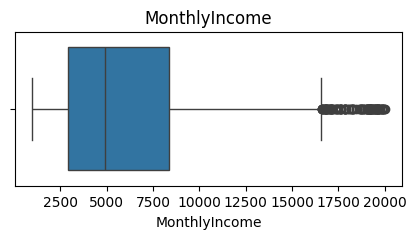

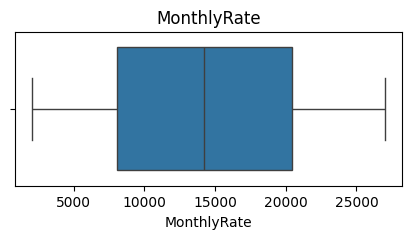

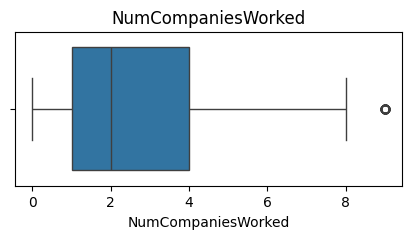

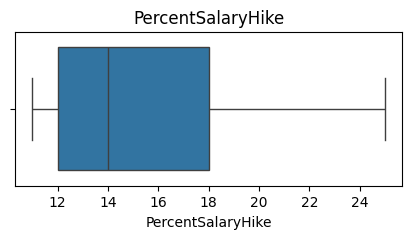

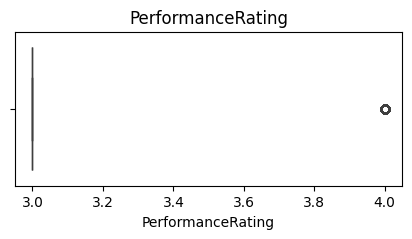

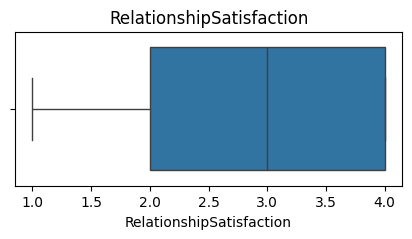

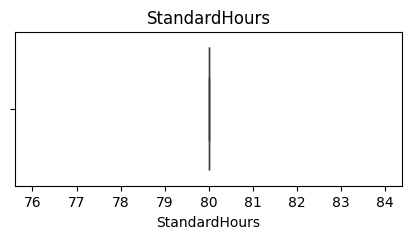

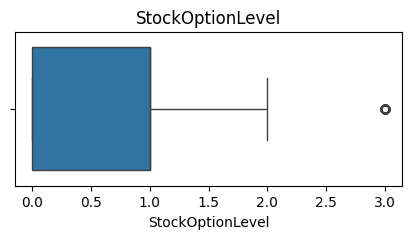

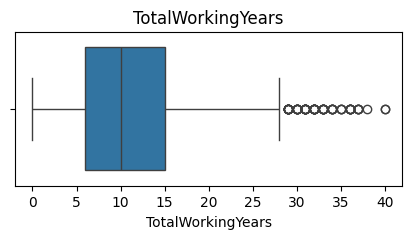

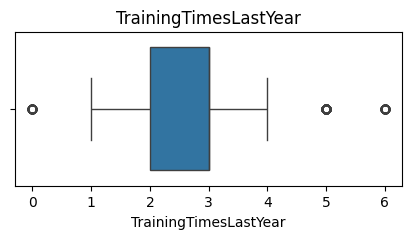

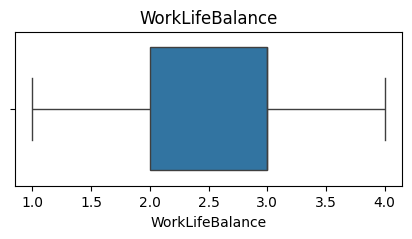

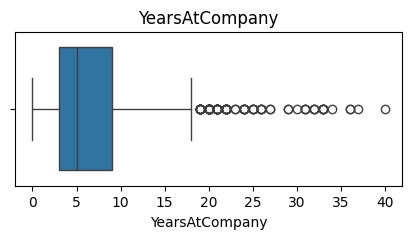

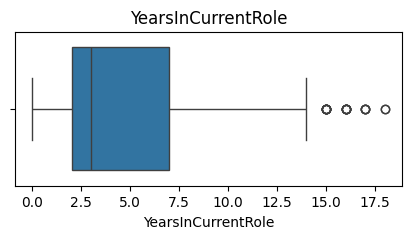

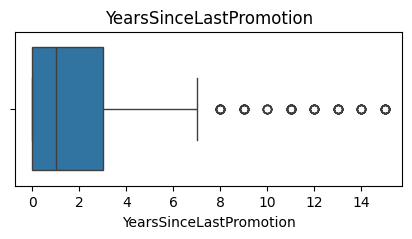

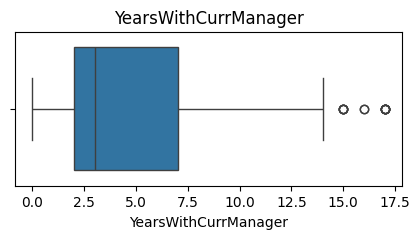

In [21]:
# @title Outlier

numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    plt.figure(figsize=(5,2))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

Berdasarkan hasil EDA, ditemukan bahwa employee dengan overtime tinggi, work-life balance rendah, dan pendapatan bulanan rendah cenderung memiliki tingkat attrition lebih tinggi. Selain itu, dataset memiliki missing value sebesar ±28% pada kolom target attrition sehingga perlu dilakukan penanganan missing value sebelum proses modeling.

# Data Preparation

In [25]:
# Pisahkan data yang memiliki null value "Attrition", untuk nantinya dilakukan prediksi

df_train = df[df['Attrition'].notnull()]
df_missing = df[df['Attrition'].isnull()]

In [26]:
# Kolom yang ingin dipakai
cols = [
    "Attrition", "MonthlyIncome", "Age", "TotalWorkingYears", "OverTime",
    "MonthlyRate", "DailyRate", "DistanceFromHome",
    "HourlyRate", "NumCompaniesWorked"
]

# Ambil hanya kolom yang dibutuhkan
df_train = df_train[cols]
df_missing = df_missing[cols]

In [27]:
# Memisahkan fitur dan target

X = df_train.drop(['Attrition'], axis=1)
y = df_train['Attrition']

In [28]:
df_train.head()

,Attrition,MonthlyIncome,Age,TotalWorkingYears,OverTime,MonthlyRate,DailyRate,DistanceFromHome,HourlyRate,NumCompaniesWorked
1,1.0,4777,37,15,No,14382,1141,11,61,5
2,1.0,2461,51,18,Yes,10332,1323,4,34,9
3,0.0,13525,42,23,No,14864,555,26,77,5
6,0.0,7457,40,6,Yes,13273,1124,1,57,2
7,1.0,19859,55,24,Yes,21199,725,2,78,5


In [29]:
# Convert kolom kategorikal ke bentu numerik
categorical_cols = X.select_dtypes(include='object').columns

le = LabelEncoder()

for col in categorical_cols:
    X[col] = le.fit_transform(X[col].astype(str))
    df_missing[col] = le.transform(df_missing[col].astype(str))

In [30]:
categorical_cols

Index(['OverTime'], dtype='object')

In [31]:
X.head()

,MonthlyIncome,Age,TotalWorkingYears,OverTime,MonthlyRate,DailyRate,DistanceFromHome,HourlyRate,NumCompaniesWorked
1,4777,37,15,0,14382,1141,11,61,5
2,2461,51,18,1,10332,1323,4,34,9
3,13525,42,23,0,14864,555,26,77,5
6,7457,40,6,1,13273,1124,1,57,2
7,19859,55,24,1,21199,725,2,78,5


In [33]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

## Data Splitting

In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## SMOTE Over-Sampling

In [35]:
# Imbalance Data Handling dengan SMOTE
smote = SMOTE(random_state=42)

X_train, y_train = smote.fit_resample(
    X_train,
    y_train
)

# Modelling

## Logistic Regression

In [36]:
lr = LogisticRegression()

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

## Random Forest

In [37]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [38]:
# @title
# Coba Pakai GridSearchCV

In [39]:
# @title
# from sklearn.model_selection import GridSearchCV

# param_grid = {
#     'n_estimators': [100, 200, 500],
#     'max_depth': [5, 10, 20],
#     'min_samples_split': [2, 5],
#     'min_samples_leaf': [1, 2],
#     'class_weight': ['balanced']
# }

# grid = GridSearchCV(
#     RandomForestClassifier(random_state=42),
#     param_grid,
#     cv=3,
#     scoring='f1',
#     n_jobs=-1
# )

# grid.fit(X_train, y_train)

In [40]:
# @title
# print(grid.best_params_)

In [41]:
# @title
# y_pred_best = best_rf.predict(X_test)

In [42]:
# @title
# print("Accuracy:",
#       accuracy_score(y_test, y_pred_best))

# print(classification_report(
#     y_test,
#     y_pred_best
# ))

In [43]:
importance_rf = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance_rf = importance_rf.sort_values(
    by='Importance',
    ascending=False
)

importance_rf.head(10)

,Feature,Importance
2,TotalWorkingYears,0.132687
1,Age,0.131463
0,MonthlyIncome,0.114701
5,DailyRate,0.114187
3,OverTime,0.105398
6,DistanceFromHome,0.104461
4,MonthlyRate,0.100705
7,HourlyRate,0.098996
8,NumCompaniesWorked,0.097401


## XGBoost

In [44]:
xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

# Evaluation

## Logistic Regression

In [45]:
print(accuracy_score(y_test, y_pred_lr))

print(classification_report(y_test, y_pred_lr))

0.6886792452830188
              precision    recall  f1-score   support

         0.0       0.91      0.69      0.79       176
         1.0       0.31      0.67      0.42        36

    accuracy                           0.69       212
   macro avg       0.61      0.68      0.60       212
weighted avg       0.81      0.69      0.72       212



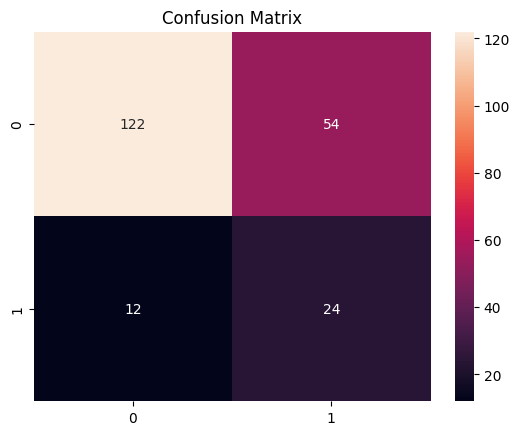

In [46]:
sns.heatmap(
    confusion_matrix(y_test, y_pred_lr),
    annot=True,
    fmt='d'
)

plt.title('Confusion Matrix')
plt.show()

## Random Forest

In [47]:
print(accuracy_score(y_test, y_pred_rf))

print(classification_report(y_test, y_pred_rf))

0.7924528301886793
              precision    recall  f1-score   support

         0.0       0.87      0.89      0.88       176
         1.0       0.38      0.33      0.35        36

    accuracy                           0.79       212
   macro avg       0.62      0.61      0.61       212
weighted avg       0.78      0.79      0.79       212



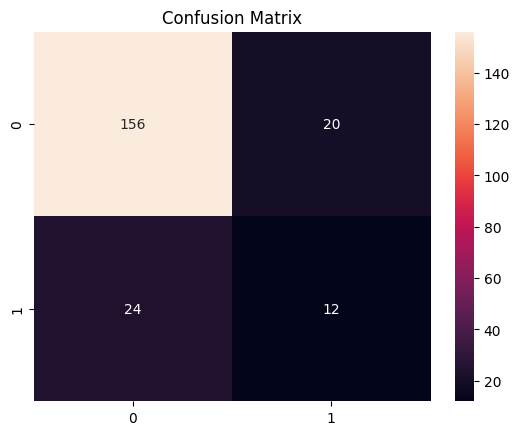

In [48]:
sns.heatmap(
    confusion_matrix(y_test, y_pred_rf),
    annot=True,
    fmt='d'
)

plt.title('Confusion Matrix')
plt.show()

In [49]:
importance_rf = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance_rf = importance_rf.sort_values(
    by='Importance',
    ascending=False
)

importance_rf.head(10)

,Feature,Importance
2,TotalWorkingYears,0.132687
1,Age,0.131463
0,MonthlyIncome,0.114701
5,DailyRate,0.114187
3,OverTime,0.105398
6,DistanceFromHome,0.104461
4,MonthlyRate,0.100705
7,HourlyRate,0.098996
8,NumCompaniesWorked,0.097401


## XGBoost

In [50]:
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))

print(classification_report(
    y_test,
    y_pred_xgb
))

Accuracy: 0.7971698113207547
              precision    recall  f1-score   support

         0.0       0.87      0.89      0.88       176
         1.0       0.39      0.36      0.38        36

    accuracy                           0.80       212
   macro avg       0.63      0.62      0.63       212
weighted avg       0.79      0.80      0.79       212



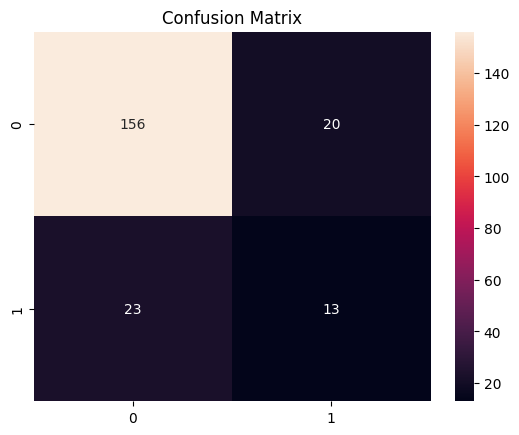

In [51]:
sns.heatmap(
    confusion_matrix(y_test, y_pred_xgb),
    annot=True,
    fmt='d'
)

plt.title('Confusion Matrix')
plt.show()

# Prediction

In [52]:
X_missing = df_missing.drop('Attrition', axis=1)

X_missing_scaled = scaler.transform(X_missing)

pred_missing_rf = rf.predict(X_missing_scaled)

In [53]:
df['Attrition_pred'] = np.nan

In [54]:
df.loc[
    df['Attrition'].isnull(),
    'Attrition_pred'
] = pred_missing_rf

In [55]:
df.head()

,EmployeeId,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,...,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition_pred
0,1,38,NaN,Travel_Frequently,1444,Human Resources,1,4,Other,1,...,80,1,7,2,3,6,2,1,2,0.0
1,2,37,1.0,Travel_Rarely,1141,Research & Development,11,2,Medical,1,...,80,0,15,2,1,1,0,0,0,NaN
2,3,51,1.0,Travel_Rarely,1323,Research & Development,4,4,Life Sciences,1,...,80,3,18,2,4,10,0,2,7,NaN
3,4,42,0.0,Travel_Frequently,555,Sales,26,3,Marketing,1,...,80,1,23,2,4,20,4,4,8,NaN
4,5,40,NaN,Travel_Rarely,1194,Research & Development,2,4,Medical,1,...,80,3,20,2,3,5,3,0,2,0.0


In [56]:
df['Attrition_final'] = df['Attrition'].fillna(
    df['Attrition_pred']
)

In [57]:
df.head()

,EmployeeId,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,...,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition_pred,Attrition_final
0,1,38,NaN,Travel_Frequently,1444,Human Resources,1,4,Other,1,...,1,7,2,3,6,2,1,2,0.0,0.0
1,2,37,1.0,Travel_Rarely,1141,Research & Development,11,2,Medical,1,...,0,15,2,1,1,0,0,0,NaN,1.0
2,3,51,1.0,Travel_Rarely,1323,Research & Development,4,4,Life Sciences,1,...,3,18,2,4,10,0,2,7,NaN,1.0
3,4,42,0.0,Travel_Frequently,555,Sales,26,3,Marketing,1,...,1,23,2,4,20,4,4,8,NaN,0.0
4,5,40,NaN,Travel_Rarely,1194,Research & Development,2,4,Medical,1,...,3,20,2,3,5,3,0,2,0.0,0.0


# Export

## Export Model

In [58]:
import pickle

In [59]:
with open('rf_attrition_model.pkl', 'wb') as file:
    pickle.dump(rf, file)

In [60]:
with open('scaler.pkl', 'wb') as file:
    pickle.dump(scaler, file)

In [61]:
with open('label_encoder.pkl', 'wb') as file:
    pickle.dump(le, file)

## Export Data Result

In [107]:
df.to_csv(
    'Data Attrition HR Jaya Maju Dicoding.csv',
    index=False
)

In [108]:
df_missing.to_excel(
    'Data Attrition HR Jaya Maju Dicoding.xlsx',
    index=False
)